<a href="https://colab.research.google.com/github/ifeomagold16ph/eye-health-data-analysis/blob/main/Glaucoma_survey.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Glaucoma Survey Analysis
**Author:** Ifeoma Ofili  
**Date:** 26 March 2026  
**Objective:** Explore survey data to understand glaucoma prevalence and identify associated risk factors.  
**Tools:** Python, Pandas, NumPy, Matplotlib  
**Dataset:** Glaucoma survey CSV



# Why these libraries?
- **Pandas:** For data cleaning, manipulation, and summarizing large datasets  
- **NumPy:** For numerical calculations and data transformations  
- **Matplotlib:** To create visualizations of trends across regions and age groups


# Step 1: Upload Data
I uploaded the dataset to the colab environment using Google colab's upload functionality. The dataset is now available for loading and preprocessing.
Using 'pd.read_csv' imports the survey data into a Pandas DataFrame.
The '.head()' function helps us quickly check column names, data types, and sample records before analysis.

In [ ]:
import pandas as pd

# Upload the CSV
from google.colab import files
uploaded = files.upload()

# Load it into a DataFrame
df = pd.read_csv('glaucoma_survey.csv')

# Quick check
df.head()

Saving glaucoma_survey.csv to glaucoma_survey.csv


,Timestamp,1. Have you heard of glaucoma?\n,Column 2,\n2. Do you think glaucoma can cause blindness?,3. Do you think you are at risk of developing glaucoma?\n,4. Do you have a family history of glaucoma?\n\n\n\n,5. When was your last eye examination?\n\n\n\n,6. What prevents you from going for regular eye check-ups?\n,7. What would most likely make you go for an eye check-up?
0,22/03/2026 19:15:18,Yes,NaN,Yes,No,Yes,Never,Fear,Family history
1,22/03/2026 19:58:58,No,NaN,Yes,Yes,No,More than 3 years ago,No symptoms,Symptoms
2,22/03/2026 20:11:12,Yes,NaN,Yes,Yes,Yes,More than 3 years ago,No symptoms,Doctor’s recommendation
3,22/03/2026 21:04:19,Yes,NaN,Yes,No,No,1-3 years ago,Cost,Symptoms
4,23/03/2026 06:48:11,Yes,NaN,Yes,No,No,Less than 1 year ago,No symptoms,Doctor’s recommendation


# Step 2: Initial Data Inspection and Cleaning
After loading the dataset, I examined the columns and found an empty column labeled "Column 2". This column contained no data and was dropped to clean up the dataset.

Following the removal, I checked the first few rows using '.head()' to verify the structure and ensure the data data loaded correctly.

In [ ]:
# Check your columns
print(df.columns)

# Drop the empty column (replace 'column 2' with the exact column name if different)
df = df.drop(columns=['Column 2'])

# Check again
df.head()

Index(['Timestamp', '1. Have you heard of glaucoma?\n', 'Column 2',
       '\n2. Do you think glaucoma can cause blindness?',
       '3. Do you think you are at risk of developing glaucoma?\n',
       '4. Do you have a family history of glaucoma?\n\n\n\n',
       '5. When was your last eye examination?\n\n\n\n',
       '6. What prevents you from going for regular eye check-ups?\n',
       '7. What would most likely make you go for an eye check-up?'],
      dtype='object')


,Timestamp,1. Have you heard of glaucoma?\n,\n2. Do you think glaucoma can cause blindness?,3. Do you think you are at risk of developing glaucoma?\n,4. Do you have a family history of glaucoma?\n\n\n\n,5. When was your last eye examination?\n\n\n\n,6. What prevents you from going for regular eye check-ups?\n,7. What would most likely make you go for an eye check-up?
0,22/03/2026 19:15:18,Yes,Yes,No,Yes,Never,Fear,Family history
1,22/03/2026 19:58:58,No,Yes,Yes,No,More than 3 years ago,No symptoms,Symptoms
2,22/03/2026 20:11:12,Yes,Yes,Yes,Yes,More than 3 years ago,No symptoms,Doctor’s recommendation
3,22/03/2026 21:04:19,Yes,Yes,No,No,1-3 years ago,Cost,Symptoms
4,23/03/2026 06:48:11,Yes,Yes,No,No,Less than 1 year ago,No symptoms,Doctor’s recommendation


# Step 3: Column Name Cleaning

The original column names contained unwanted characters such as '\n' (newline) and extra spaces. I cleaned them by:
- Removing '\n' characters
- Stripping leading and trailing spaces
- Replacing multiple spaces with single spaces where necessary.

In [ ]:
# Clean all column names by removing \n and extra spaces
df.columns = [col.replace('\\', '').strip() for col in df.columns]

print(df.columns)  # Check the results

Index(['Timestamp', '1. Have you heard of glaucoma?',
       '2. Do you think glaucoma can cause blindness?',
       '3. Do you think you are at risk of developing glaucoma?',
       '4. Do you have a family history of glaucoma?',
       '5. When was your last eye examination?',
       '6. What prevents you from going for regular eye check-ups?',
       '7. What would most likely make you go for an eye check-up?'],
      dtype='object')


# Step 4: Final Column Names (shortened)
To improve readability and ease of analysis, I shortened the column names to more concise versions while preserving their meaning.

In [ ]:
# Final clean column names (makes them shorter and nicer for analysis)
df.columns = [
    'Timestamps',
    'Heard_of_glaucoma',
    'Glaucoma_causes_blindness',
    'At_risk_of_glaucoma',
    'Family_history_glaucoma',
    'Last_eye_exam',
    'Prevents_regular_checkup',
    'What_would_make_you_go'
]

print(df.columns)
df.head()

Index(['Timestamps', 'Heard_of_glaucoma', 'Glaucoma_causes_blindness',
       'At_risk_of_glaucoma', 'Family_history_glaucoma', 'Last_eye_exam',
       'Prevents_regular_checkup', 'What_would_make_you_go'],
      dtype='object')


,Timestamps,Heard_of_glaucoma,Glaucoma_causes_blindness,At_risk_of_glaucoma,Family_history_glaucoma,Last_eye_exam,Prevents_regular_checkup,What_would_make_you_go
0,22/03/2026 19:15:18,Yes,Yes,No,Yes,Never,Fear,Family history
1,22/03/2026 19:58:58,No,Yes,Yes,No,More than 3 years ago,No symptoms,Symptoms
2,22/03/2026 20:11:12,Yes,Yes,Yes,Yes,More than 3 years ago,No symptoms,Doctor’s recommendation
3,22/03/2026 21:04:19,Yes,Yes,No,No,1-3 years ago,Cost,Symptoms
4,23/03/2026 06:48:11,Yes,Yes,No,No,Less than 1 year ago,No symptoms,Doctor’s recommendation


In [ ]:
import pandas as pd
from google.colab import files

# If the file is not loaded, uncomment the next line and upload it
# uploaded = files.upload()

df = pd.read_csv('glaucoma_survey.csv')

# Re-apply your clean column names (just in case)
df.columns = [col.replace('\n', ' ').strip() for col in df.columns]

df.columns = [
    'Timestamp',
    'Heard_of_glaucoma',
    'Glaucoma_causes_blindness',
    'At_risk_of_glaucoma',
    'Family_history_glaucoma',
    'Last_eye_exam',
    'Prevents_regular_checkup',
    'What_would_make_checkup'
]

print("✅ df is now ready!")
print("Columns:", df.columns.tolist())
display(df.head(6))   # Shows first 6 rows so we can see your data


# Step 5: Re-running After Runtime Expiration
The colab runtime expired, causing the uploaded file to be lost. To recover, I re-ran all the preprocessing steps from the beginning:
- Re-uploaded the dataset
- Dropped the empty column
- Cleaned column names
- Shortened column names

The dataset is now ready for analysis again

In [ ]:
import pandas as pd
from google.colab import files

# Upload the file again (please select glaucoma_survey.csv)
print("Upload your file now...")
uploaded = files.upload()

filename = list(uploaded.keys())[0]
print(f"Uploaded: {filename}")

# Load without assuming column count
df = pd.read_csv(filename)

print("\nOriginal columns (before cleaning):")
print(df.columns.tolist())
print(f"Number of columns: {df.shape[1]}")
print(f"Number of rows: {df.shape[0]}")

# Step 1: Basic cleaning of messy names
df.columns = [str(col).replace('\n', ' ').strip() for col in df.columns]

# Step 2: Drop any empty or useless column automatically
df = df.loc[:, ~df.columns.str.contains('^Unnamed|^Column 2|^\s*$', case=False, na=False)]

# Step 3: Now assign clean short names (dynamically safe way)
clean_names = [
    'Timestamp',
    'Heard_of_glaucoma',
    'Glaucoma_causes_blindness',
    'At_risk_of_glaucoma',
    'Family_history_glaucoma',
    'Last_eye_exam',
    'Prevents_regular_checkup',
    'What_would_make_checkup'
]

# If there's still one extra column, drop the last one or rename safely
if len(df.columns) > len(clean_names):
    print(f"\nWarning: {len(df.columns)} columns found, keeping first 8")
    df = df.iloc[:, :8]   # keep only first 8 columns

df.columns = clean_names

print("\n✅ Final cleaned columns:")
print(df.columns.tolist())

# Show the data
display(df.head(10))
print("\nMissing values:")
print(df.isnull().sum())


Upload your file now...


<>:23: SyntaxWarning: invalid escape sequence '\s'
<>:23: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_7542/1754300554.py:23: SyntaxWarning: invalid escape sequence '\s'
  df = df.loc[:, ~df.columns.str.contains('^Unnamed|^Column 2|^\s*$', case=False, na=False)]


Saving glaucoma_survey.csv to glaucoma_survey (1).csv
Uploaded: glaucoma_survey (1).csv

Original columns (before cleaning):
['Timestamp', '1. Have you heard of glaucoma?\n', 'Column 2', '\n2. Do you think glaucoma can cause blindness?', '3. Do you think you are at risk of developing glaucoma?\n', '4. Do you have a family history of glaucoma?\n\n\n\n', '5. When was your last eye examination?\n\n\n\n', '6. What prevents you from going for regular eye check-ups?\n', '7. What would most likely make you go for an eye check-up?']
Number of columns: 9
Number of rows: 42

✅ Final cleaned columns:
['Timestamp', 'Heard_of_glaucoma', 'Glaucoma_causes_blindness', 'At_risk_of_glaucoma', 'Family_history_glaucoma', 'Last_eye_exam', 'Prevents_regular_checkup', 'What_would_make_checkup']


,Timestamp,Heard_of_glaucoma,Glaucoma_causes_blindness,At_risk_of_glaucoma,Family_history_glaucoma,Last_eye_exam,Prevents_regular_checkup,What_would_make_checkup
0,22/03/2026 19:15:18,Yes,Yes,No,Yes,Never,Fear,Family history
1,22/03/2026 19:58:58,No,Yes,Yes,No,More than 3 years ago,No symptoms,Symptoms
2,22/03/2026 20:11:12,Yes,Yes,Yes,Yes,More than 3 years ago,No symptoms,Doctor’s recommendation
3,22/03/2026 21:04:19,Yes,Yes,No,No,1-3 years ago,Cost,Symptoms
4,23/03/2026 06:48:11,Yes,Yes,No,No,Less than 1 year ago,No symptoms,Doctor’s recommendation
5,23/03/2026 12:42:31,Yes,Yes,Yes,Yes,1-3 years ago,No symptoms,Awareness/education
6,23/03/2026 13:40:48,Yes,Yes,No,No,1-3 years ago,No symptoms,Awareness/education
7,23/03/2026 14:58:23,Yes,Yes,Not sure,Yes,1-3 years ago,Fear,Awareness/education
8,23/03/2026 16:17:08,Yes,Yes,No,No,Never,No symptoms,Symptoms
9,23/03/2026 16:41:30,Yes,Yes,No,No,Less than 1 year ago,No symptoms,Symptoms



Missing values:
Timestamp                    0
Heard_of_glaucoma            0
Glaucoma_causes_blindness    0
At_risk_of_glaucoma          0
Family_history_glaucoma      0
Last_eye_exam                0
Prevents_regular_checkup     0
What_would_make_checkup      0
dtype: int64


In [ ]:
print("✅ Checking if df is ready...")
print(" Shape (rows, columns):", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nFirst few rows of your data:")
display(df.head(8))

✅ Checking if df is ready...
 Shape (rows, columns): (42, 8)

Column names:
['Timestamp', 'Heard_of_glaucoma', 'Glaucoma_causes_blindness', 'At_risk_of_glaucoma', 'Family_history_glaucoma', 'Last_eye_exam', 'Prevents_regular_checkup', 'What_would_make_checkup']

First few rows of your data:


,Timestamp,Heard_of_glaucoma,Glaucoma_causes_blindness,At_risk_of_glaucoma,Family_history_glaucoma,Last_eye_exam,Prevents_regular_checkup,What_would_make_checkup
0,22/03/2026 19:15:18,Yes,Yes,No,Yes,Never,Fear,Family history
1,22/03/2026 19:58:58,No,Yes,Yes,No,More than 3 years ago,No symptoms,Symptoms
2,22/03/2026 20:11:12,Yes,Yes,Yes,Yes,More than 3 years ago,No symptoms,Doctor’s recommendation
3,22/03/2026 21:04:19,Yes,Yes,No,No,1-3 years ago,Cost,Symptoms
4,23/03/2026 06:48:11,Yes,Yes,No,No,Less than 1 year ago,No symptoms,Doctor’s recommendation
5,23/03/2026 12:42:31,Yes,Yes,Yes,Yes,1-3 years ago,No symptoms,Awareness/education
6,23/03/2026 13:40:48,Yes,Yes,No,No,1-3 years ago,No symptoms,Awareness/education
7,23/03/2026 14:58:23,Yes,Yes,Not sure,Yes,1-3 years ago,Fear,Awareness/education


# Step 6: Data Summary and Missing Values

I performed a comprehensive data check including:
- **Total number of responses**: 42
- **Column list**: Verified all columns are present
- **Missing values**: Checked for null values across all columns
- **Response summaries**: For all 42 responses, I summarized the counts for each column to understand the distribution of answers


In [ ]:
print(f"Total responses: {df.shape[0]}\n")

print("Missing values per column:")
print(df.isnull().sum())

print("\n" + "="*70)
print("FULL SUMMARY WITH PERCENTAGES (42 responses)")
print("="*70)

for col in df.columns[1:]:   # skip Timestamp
    print(f"\n🔹 {col}:")
    counts = df[col].value_counts(dropna=False)
    percentages = df[col].value_counts(normalize=True, dropna=False) * 100

    for value in counts.index:
        print(f"   {value:30} → {counts[value]:2d} responses ({percentages[value]:4.1f}%)")
    print("-" * 60)


Total responses: 42

Missing values per column:
Timestamp                    0
Heard_of_glaucoma            0
Glaucoma_causes_blindness    0
At_risk_of_glaucoma          0
Family_history_glaucoma      0
Last_eye_exam                0
Prevents_regular_checkup     0
What_would_make_checkup      0
dtype: int64

FULL SUMMARY WITH PERCENTAGES (42 responses)

🔹 Heard_of_glaucoma:
   Yes                            → 40 responses (95.2%)
   No                             →  2 responses ( 4.8%)
------------------------------------------------------------

🔹 Glaucoma_causes_blindness:
   Yes                            → 40 responses (95.2%)
   Not sure                       →  2 responses ( 4.8%)
------------------------------------------------------------

🔹 At_risk_of_glaucoma:
   No                             → 20 responses (47.6%)
   Not sure                       → 12 responses (28.6%)
   Yes                            → 10 responses (23.8%)
------------------------------------------------

The survey (N=42) revealed that while awareness of glaucoma is high (95% had heard of it) and perceived severity is strong (93% believe it causes blindness), perceived susceptibility remains low. The dominant barrier to regular eye check-ups is “no symptoms” (54.8%), followed by cost and lack of time. The most powerful cues to action identified were the appearance of symptoms (52.4%) and increased awareness/education (31.0%). These findings guided the design of a Health Belief Model-based communication intervention that emphasises the asymptomatic nature of early glaucoma and promotes proactive screening through educational messaging and digital outreach.


# Step 7: Runtime Expired – Dataset Reloaded

The Colab runtime expired again, resulting in the loss of the uploaded file. I reloaded the dataset and re-ran the necessary preprocessing steps to continue the analysis.


In [ ]:
import pandas as pd
from google.colab import files

print("📤 Please upload your glaucoma_survey.csv file again...")
uploaded = files.upload()

filename = list(uploaded.keys())[0]

# Load the file
df = pd.read_csv(filename)

# Clean column names (removes \n and extra spaces)
df.columns = [str(col).replace('\n', ' ').strip() for col in df.columns]

# Remove any extra empty column if it exists
df = df.loc[:, ~df.columns.str.contains('^Unnamed|^Column 2|^$', case=False)]

# Assign clean short names
df.columns = [
    'Timestamp',
    'Heard_of_glaucoma',
    'Glaucoma_causes_blindness',
    'At_risk_of_glaucoma',
    'Family_history_glaucoma',
    'Last_eye_exam',
    'Prevents_regular_checkup',
    'What_would_make_checkup'
]

print("✅ df is now ready!")
print(f"Total responses: {df.shape[0]}")
print("Columns:", df.columns.tolist())

# Show first few rows to confirm
display(df.head(5))


📤 Please upload your glaucoma_survey.csv file again...


Saving glaucoma_survey.csv to glaucoma_survey.csv
✅ df is now ready!
Total responses: 42
Columns: ['Timestamp', 'Heard_of_glaucoma', 'Glaucoma_causes_blindness', 'At_risk_of_glaucoma', 'Family_history_glaucoma', 'Last_eye_exam', 'Prevents_regular_checkup', 'What_would_make_checkup']


,Timestamp,Heard_of_glaucoma,Glaucoma_causes_blindness,At_risk_of_glaucoma,Family_history_glaucoma,Last_eye_exam,Prevents_regular_checkup,What_would_make_checkup
0,22/03/2026 19:15:18,Yes,Yes,No,Yes,Never,Fear,Family history
1,22/03/2026 19:58:58,No,Yes,Yes,No,More than 3 years ago,No symptoms,Symptoms
2,22/03/2026 20:11:12,Yes,Yes,Yes,Yes,More than 3 years ago,No symptoms,Doctor’s recommendation
3,22/03/2026 21:04:19,Yes,Yes,No,No,1-3 years ago,Cost,Symptoms
4,23/03/2026 06:48:11,Yes,Yes,No,No,Less than 1 year ago,No symptoms,Doctor’s recommendation


# Step 8: HBM (Health Belief Model) Visualizations

Based on the Health Belief Model framework, I created the following charts to understand key constructs:

### 8.1 Main Barriers
What prevents you from regular eye checkups? (vs. Number of responses)

### 8.2 Main Motivators
What would most likely make you go for an eye checkup? (vs. Number of responses)

### 8.3 Perceived Risk
Do you think you are at risk of developing glaucoma? (vs. Number of responses)

### 8.4 Last Eye Exam
When was your last eye examination? (vs. Number of responses)


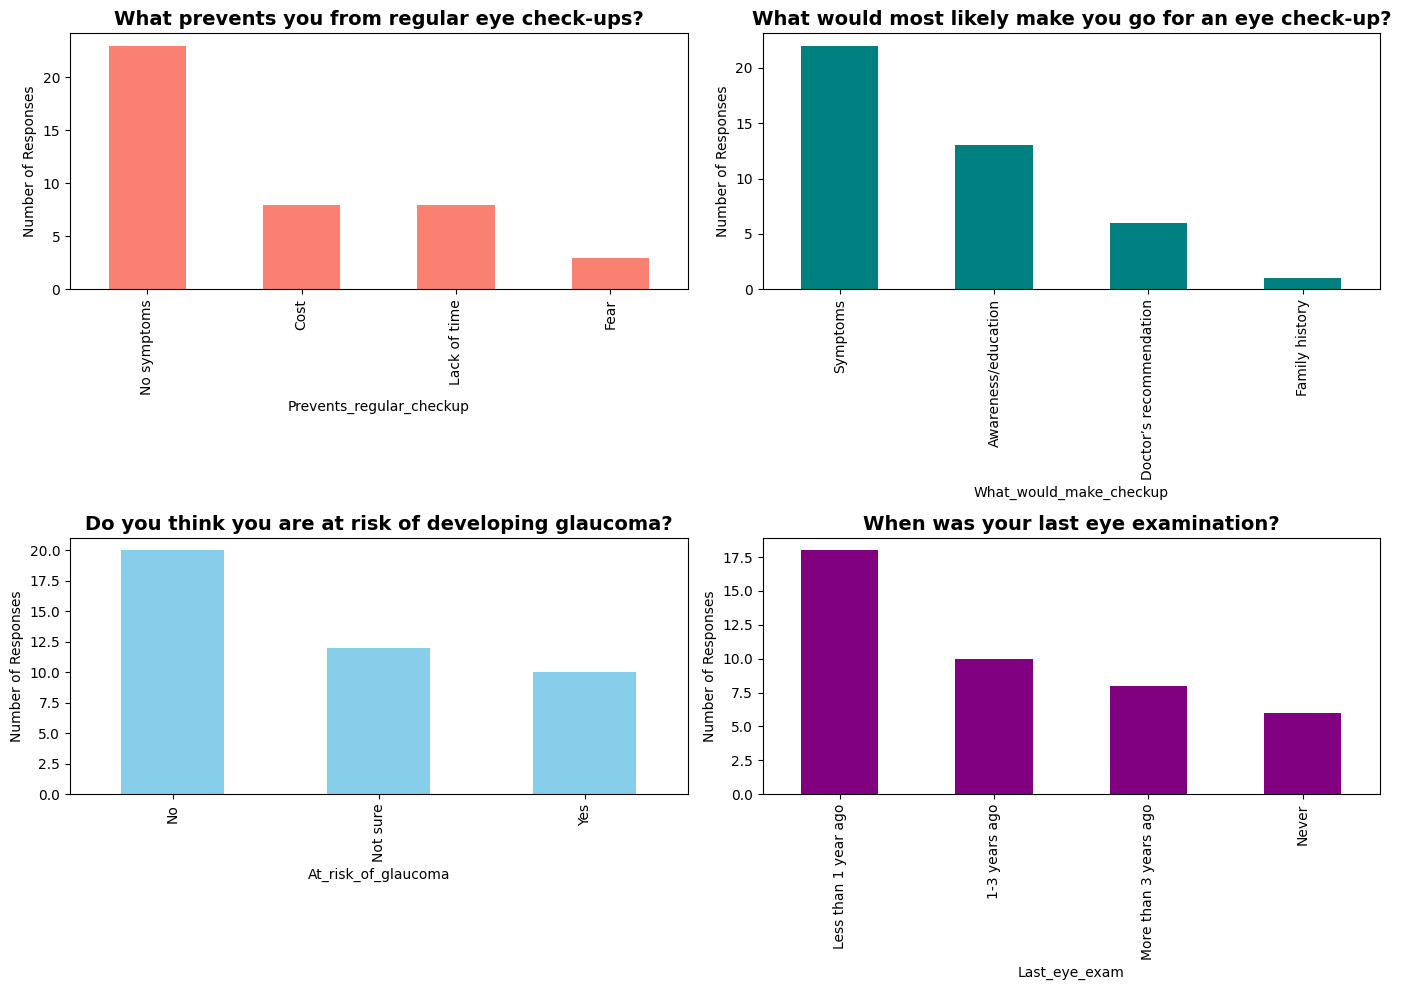

✅ Charts created and saved as 'Glaucoma_Survey_Charts.png'


In [ ]:
import matplotlib.pyplot as plt

# Make charts a good size
plt.rcParams['figure.figsize'] = (14, 10)

fig, axes = plt.subplots(2, 2)

# Chart 1: Main Barriers
df['Prevents_regular_checkup'].value_counts().plot(kind='bar', ax=axes[0,0], color='salmon')
axes[0,0].set_title('What prevents you from regular eye check-ups?', fontsize=14, fontweight='bold')
axes[0,0].set_ylabel('Number of Responses')

# Chart 2: Main Motivators
df['What_would_make_checkup'].value_counts().plot(kind='bar', ax=axes[0,1], color='teal')
axes[0,1].set_title('What would most likely make you go for an eye check-up?', fontsize=14, fontweight='bold')
axes[0,1].set_ylabel('Number of Responses')

# Chart 3: Perceived Risk
df['At_risk_of_glaucoma'].value_counts().plot(kind='bar', ax=axes[1,0], color='skyblue')
axes[1,0].set_title('Do you think you are at risk of developing glaucoma?', fontsize=14, fontweight='bold')
axes[1,0].set_ylabel('Number of Responses')

# Chart 4: Last Eye Exam
df['Last_eye_exam'].value_counts().plot(kind='bar', ax=axes[1,1], color='purple')
axes[1,1].set_title('When was your last eye examination?', fontsize=14, fontweight='bold')
axes[1,1].set_ylabel('Number of Responses')

plt.tight_layout()
plt.show()

# Save the charts as an image (for your report or presentation)
fig.savefig('Glaucoma_Survey_Charts.png', dpi=300, bbox_inches='tight')
print("✅ Charts created and saved as 'Glaucoma_Survey_Charts.png'")


The survey (N=42) revealed strong awareness of glaucoma, with 95% of respondents having heard of the condition and 93% correctly believing it can cause blindness. This indicates high perceived severity according to the Health Belief Model. However, perceived susceptibility remains low — only 24% of participants felt they were personally at risk of developing glaucoma.
The dominant barrier to preventive eye care was “No symptoms” (54.8%), followed by cost (19.0%) and lack of time (19.0%). This finding highlights a classic Health Belief Model gap: individuals are unlikely to seek screening when they feel healthy. The most powerful cues to action identified were the appearance of symptoms (52.4%) and increased awareness/education (31.0%), with doctor’s recommendation also noted by 14.3%.
These results directly informed the design of a targeted health communication intervention. Educational messages and digital outreach were developed to emphasise the asymptomatic (“silent”) nature of early glaucoma, increase perceived personal risk, and promote proactive screening.


In [ ]:
# Export clean summary + percentages to Excel
summary = pd.DataFrame()
for col in df.columns[1:]:
    counts = df[col].value_counts(dropna=False)
    percentages = df[col].value_counts(normalize=True, dropna=False) * 100
    temp = pd.DataFrame({
        'Response': counts.index,
        'Count': counts.values,
        'Percentage': percentages.values
    })
    temp['Question'] = col
    summary = pd.concat([summary, temp])

summary = summary[['Question', 'Response', 'Count', 'Percentage']]
summary.to_excel('Glaucoma_Survey_Summary.xlsx', index=False)

print("✅ Summary exported to 'Glaucoma_Survey_Summary.xlsx'")
print("✅ Charts saved as 'Glaucoma_Survey_Charts.png'")


✅ Summary exported to 'Glaucoma_Survey_Summary.xlsx'
✅ Charts saved as 'Glaucoma_Survey_Charts.png'


In [ ]:
from google.colab import files

files.download('Glaucoma_Survey_Summary.xlsx')
files.download('Glaucoma_Survey_Charts.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Step 9: Cross-Analysis

To explore relationships between key variables, I performed cross-tabulation analyses:

### 9.1 Family History vs. Perceived Personal Risk
- **Cross 1**: `pd.crosstab(df['Family_history_glaucoma'], df['At_risk_of_glaucoma'], margins=True)`
- **Cross Percent**: `pd.crosstab(df['Family_history_glaucoma'], df['At_risk_of_glaucoma'], normalize='index') * 100`

This analysis shows the relationship between having a family history of glaucoma and whether individuals perceive themselves to be at risk.

### 9.2 Perceived Risk vs. Main Barriers
Cross-tabulation between perceived risk levels and the barriers preventing regular eye checkups.

### 9.3 Last Eye Exam vs. Main Barrier
Cross-tabulation between the timing of the last eye examination and the main barriers reported.


In [ ]:
# Cross- analysis; Family History Vs Perceived Personal Risk

print("Family History of Glaucoma vs Perceived Risk")
cross1 = pd.crosstab(df['Family_history_glaucoma'],
                     df['At_risk_of_glaucoma'],
                     margins=True)

cross1_percent = pd.crosstab(df['Family_history_glaucoma'],
                             df['At_risk_of_glaucoma'],
                             normalize='index') * 100

print(cross1)
print("\nPercentages within each family history group:")
print(cross1_percent.round(1))


Family History of Glaucoma vs Perceived Risk
At_risk_of_glaucoma      No  Not sure  Yes  All
Family_history_glaucoma                        
No                       17         6    4   27
Not sure                  2         3    0    5
Yes                       1         3    6   10
All                      20        12   10   42

Percentages within each family history group:
At_risk_of_glaucoma        No  Not sure   Yes
Family_history_glaucoma                      
No                       63.0      22.2  14.8
Not sure                 40.0      60.0   0.0
Yes                      10.0      30.0  60.0


A cross-tabulation analysis revealed a clear relationship between family history and perceived susceptibility. Among respondents with no family history (n=27), only 14.8% believed they were at risk of developing glaucoma, while 63% felt they were not at risk. In contrast, among those with a positive family history (n=10), 60% perceived themselves to be at risk — more than four times higher than the no-family-history group. Respondents who were unsure about their family history (n=5) showed intermediate levels of uncertainty.
This finding supports the Health Belief Model: a known family history serves as a powerful cue to action that significantly increases perceived personal susceptibility. It highlights the value of incorporating family history screening questions in educational campaigns to help individuals recognise their own risk, even in the absence of symptoms.


In [ ]:
# Cross- analysis: Perceived Risk Vs Main Barrier


print("Perceived Risk vs What Prevents Regular Check-ups")
cross2 = pd.crosstab(df['At_risk_of_glaucoma'],
                     df['Prevents_regular_checkup'],
                     margins=True)
print(cross2)


Perceived Risk vs What Prevents Regular Check-ups
Prevents_regular_checkup  Cost  Fear  Lack of time  No symptoms  All
At_risk_of_glaucoma                                                 
No                           5     1             3           11   20
Not sure                     2     2             4            4   12
Yes                          1     0             1            8   10
All                          8     3             8           23   42


Cross-tabulation between perceived susceptibility and barriers showed a meaningful pattern. Among respondents who felt they were not at risk (n=20), 55% (11 people) cited “No symptoms” as the main barrier to regular eye check-ups. In comparison, among those who did feel at risk (n=10), only 40% (4 people) selected “No symptoms”. Respondents who were “Not sure” about their risk (n=12) fell in between.
This supports the Health Belief Model: individuals with low perceived susceptibility are significantly more likely to be deterred by the absence of symptoms. It reinforces the need for educational messages that explicitly address the “silent” progression of glaucoma.


In [ ]:
# Cross- analysis: Last Eye Exam Vs Main Barrier

print("Last Eye Examination vs Main Barrier")
cross3 = pd.crosstab(df['Last_eye_exam'],
                     df['Prevents_regular_checkup'],
                     margins=True)
print(cross3)


Last Eye Examination vs Main Barrier
Prevents_regular_checkup  Cost  Fear  Lack of time  No symptoms  All
Last_eye_exam                                                       
1-3 years ago                3     1             0            6   10
Less than 1 year ago         3     0             7            8   18
More than 3 years ago        2     0             1            5    8
Never                        0     2             0            4    6
All                          8     3             8           23   42


Analysis of last eye examination and barriers revealed that participants who had never had an eye exam (n=6) or whose last exam was more than 3 years ago (n=8) reported “No symptoms” as the dominant barrier (67% and 62.5% respectively). In contrast, those who had a more recent eye exam (less than 1 year or 1–3 years ago) showed more varied barriers, including cost and lack of time.
This suggests that people who have not engaged with eye care services for a long time are particularly trapped in the “no symptoms = no need” mindset. It highlights an important opportunity for targeted reminders and awareness campaigns aimed at those with outdated or no screening history.


**Results & Discussion**

The survey collected 42 valid responses. Awareness of glaucoma was very high (95% had heard of it) and perceived severity was strong, with 93% correctly believing that glaucoma can cause blindness. These findings indicate that knowledge of the disease and its consequences is already well established in the sample.
However, perceived susceptibility remained low overall (only 24% felt they were personally at risk). A cross-tabulation with family history revealed a strong relationship: among participants with a positive family history (n=10), 60% believed they were at risk, compared with only 14.8% of those with no family history (n=27). Respondents unsure about their family history (n=5) showed the highest uncertainty. This pattern demonstrates that a known family history acts as a powerful cue to action, significantly increasing perceived personal risk.
Barriers to regular eye check-ups were dominated by “No symptoms” (54.8%, n=23), followed by cost and lack of time (both 19.0%). Cross-analysis between perceived risk and barriers showed that individuals who felt they were not at risk were the most likely to cite “No symptoms” as the main obstacle (55%), while those who felt at risk reported more varied barriers. Similarly, participants whose last eye examination was more than 3 years ago or who had never had an eye exam were particularly likely to be deterred by the absence of symptoms (62.5% and 67% respectively). In contrast, those with more recent eye exams showed greater diversity in barriers, including cost and lack of time.
These results align closely with the Health Belief Model. While perceived severity is high, low perceived susceptibility and the dominant “No symptoms” barrier create a clear gap between knowledge and preventive behaviour. The strongest cues to action identified were the appearance of symptoms (52.4%) and increased awareness/education (31.0%).

**Implications for Intervention**

The findings directly guided the design of the health communication intervention. Educational messages and digital outreach now emphasise the asymptomatic (“silent”) nature of early glaucoma, highlight family history as a personal risk factor, and promote proactive screening even in the absence of symptoms. By addressing low perceived susceptibility and the “no symptoms” barrier, the intervention aims to increase regular eye examinations among at-risk populations.

